# GBM overfit sanity check

Tests whether the model has overfitted to the `toy_gbm` dataset.
The key difference from `Toy_analysis.ipynb`: GBM log-prices are **non-stationary**
— the marginal distribution of X_t is N(0, t·σ²), so flattening all values and
running a single KS test is meaningless. This notebook runs three complementary tests:

1. **Increment test** — ΔX_t = X_t − X_{t-1} should be i.i.d. N(0, σ²). Reuses the
   KS / QQ / histogram pipeline from `Toy_analysis` but applied to first differences.
2. **Variance fan** — Var[X_t] must grow linearly with t (the defining property of a
   random walk). Saturation ⟹ the model collapsed to something AR(1)-like.
3. **ACF of levels vs. increments** — levels should have ACF ≈ 1 at all lags;
   increments should have ACF ≈ 0. Reveals whether temporal structure was learned.

In [10]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "../checkpoints/toy/NO_TOY_GBM_UNCO_ep-500_step-2500_sde-vp_noise-linear_lr-1e-04_N-2000_notlinear_layers-4_nheads-8_diffemb-256_20260403_110543.pt"
REF_STD   = 1.0    # GBM increment std (must match toy_generation.py)
N_SAMPLES = 256    # sequences to generate
N_STEPS   = 2000   # reverse SDE steps (None = model config default)
SEED      = 0
# ─────────────────────────────────────────────────────────────────────────────

In [11]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats as scipy_stats
from statsmodels.graphics.tsaplots import plot_acf

from src.models.model_core import CSDIModel
from src.utils.WIP_processes import Diffusion_Processes

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [12]:
DATA_DIR = "../data/toy_gbm"
SEQ_LEN  = 64   # must match training seq_len

# ── Load all CSVs ─────────────────────────────────────────────────────────────
from pathlib import Path

csv_files = sorted(Path(DATA_DIR).glob("*.csv"))
paths_list = [pd.read_csv(f)["log_adj_close"].values.astype(np.float64)
              for f in csv_files]

all_paths = np.stack(paths_list)          # (N_PATHS, SEQ_LEN)
N_PATHS   = len(all_paths)
flat      = all_paths.ravel()             # all values flattened

# ── 1. Aggregate level statistics ─────────────────────────────────────────────
print("=" * 55)
print(f"  TRAINING DATA  ({N_PATHS} paths × {SEQ_LEN} steps)")
print("=" * 55)
print(f"  Total values    : {len(flat):,}")
print(f"  Mean            : {flat.mean():.4f}   (expected ≈ 0, all paths anchored at 0)")
print(f"  Std             : {flat.std():.4f}   (expected ≈ √(SEQ_LEN/3) ≈ {np.sqrt(SEQ_LEN/3):.2f})")
print(f"  Min / Max       : {flat.min():.4f} / {flat.max():.4f}")
print(f"  Skewness        : {scipy_stats.skew(flat):.4f}   (expected ≈ 0)")
print(f"  Excess kurtosis : {scipy_stats.kurtosis(flat, fisher=True):.4f}   (expected ≈ 0)")

# ── 2. Increment statistics ───────────────────────────────────────────────────
# np.diff across axis=1: shape (N_PATHS, SEQ_LEN-1)
all_inc = np.diff(all_paths, axis=1).ravel()

print()
print("=" * 55)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}")
print("=" * 55)
print(f"  Total increments: {len(all_inc):,}")
print(f"  Mean            : {all_inc.mean():.6f}   (expected = 0)")
print(f"  Std             : {all_inc.std():.6f}   (expected = {REF_STD:.1f})")
print(f"  Min / Max       : {all_inc.min():.4f} / {all_inc.max():.4f}")
print(f"  Skewness        : {scipy_stats.skew(all_inc):.4f}   (expected = 0)")
print(f"  Excess kurtosis : {scipy_stats.kurtosis(all_inc, fisher=True):.4f}   (expected = 0)")

# ── 3. Per-path statistics ────────────────────────────────────────────────────
path_endpoints = all_paths[:, -1]          # X_{seq_len-1} per path
path_absmax    = np.abs(all_paths).max(axis=1)
path_stds      = all_paths.std(axis=1)

print()
print("=" * 55)
print("  PER-PATH STATISTICS")
print("=" * 55)
print(f"  X_0 (should all be 0)   : min={all_paths[:,0].min():.4f}  max={all_paths[:,0].max():.4f}")
print(f"  End-point X_{{T}}         : "
      f"mean={path_endpoints.mean():.4f}  "
      f"std={path_endpoints.std():.4f}  "
      f"(expected std = √{SEQ_LEN} = {np.sqrt(SEQ_LEN):.2f})")
print(f"  Per-path |max value|    : "
      f"p50={np.percentile(path_absmax, 50):.2f}  "
      f"p95={np.percentile(path_absmax, 95):.2f}  "
      f"max={path_absmax.max():.2f}")
print(f"  Per-path std            : "
      f"p50={np.percentile(path_stds, 50):.2f}  "
      f"p95={np.percentile(path_stds, 95):.2f}  "
      f"max={path_stds.max():.2f}")

# ── 4. Variance growth check ──────────────────────────────────────────────────
# var_t     = all_paths.var(axis=0)          # Var[X_t] across paths, shape (SEQ_LEN,)
# t_axis    = np.arange(SEQ_LEN)
# slope, _, r, _, _ = scipy_stats.linregress(t_axis[1:], var_t[1:])  # skip t=0 (always 0)

# print()
# print("=" * 55)
# print("  VARIANCE GROWTH  Var[X_t] vs t")
# print("=" * 55)
# print(f"  Slope (empirical)       : {slope:.4f}   (expected = σ² = {REF_STD**2:.1f})")
# print(f"  R² of linear fit        : {r**2:.4f}   (expected ≈ 1.0)")
# print(f"  Var at t={SEQ_LEN-1:2d}           : {var_t[-1]:.2f}   "
#       f"(expected ≈ {(SEQ_LEN-1) * REF_STD**2:.0f})")

# ── 5. sigma_max guidance ─────────────────────────────────────────────────────
print()
print("=" * 55)
print("  SIGMA_MAX GUIDANCE  (VE-SDE)")
print("=" * 55)
print(f"  Increment std (data scale)          : {all_inc.std():.3f}")
print(f"  Max |value| across all paths        : {path_absmax.max():.2f}")
print(f"  Suggested sigma_max (5 × max|val|)  : {5 * path_absmax.max():.0f}")

  TRAINING DATA  (156 paths × 64 steps)
  Total values    : 9,984
  Mean            : 0.0470   (expected ≈ 0, all paths anchored at 0)
  Std             : 5.3572   (expected ≈ √(SEQ_LEN/3) ≈ 4.62)
  Min / Max       : -17.9057 / 24.8813
  Skewness        : -0.0453   (expected ≈ 0)
  Excess kurtosis : 0.9668   (expected ≈ 0)

  INCREMENTS  ΔX_t = X_t − X_{t−1}
  Total increments: 9,828
  Mean            : -0.004649   (expected = 0)
  Std             : 1.002417   (expected = 1.0)
  Min / Max       : -3.9068 / 4.1854
  Skewness        : 0.0267   (expected = 0)
  Excess kurtosis : 0.1143   (expected = 0)

  PER-PATH STATISTICS
  X_0 (should all be 0)   : min=0.0000  max=0.0000
  End-point X_{T}         : mean=-0.2929  std=7.7220  (expected std = √64 = 8.00)
  Per-path |max value|    : p50=7.92  p95=15.97  max=24.88
  Per-path std            : p50=2.63  p95=4.88  max=8.31

  SIGMA_MAX GUIDANCE  (VE-SDE)
  Increment std (data scale)          : 1.002
  Max |value| across all paths        : 24.

## 1. Load checkpoint

In [13]:
ckpt   = torch.load(CHECKPOINT_PATH, map_location=device)
config = ckpt["config"]

target_dim = int(config["data"]["target_dim"])
seq_len    = int(config["train"]["seq_len"])

processes = Diffusion_Processes(config["process"])

model = CSDIModel(target_dim=target_dim, config=config, device=device).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Checkpoint epoch : {ckpt.get('epoch', '?')}")
print(f"target_dim={target_dim}  seq_len={seq_len}")
print(f"SDE: {config['process']['sde_type']}")

print("Config:\n", config)

Checkpoint epoch : 499
target_dim=1  seq_len=64
SDE: vp
Config:
 {'data': {'target_dim': 1}, 'model': {'timeemb': 256, 'featureemb': 64, 'is_unconditional': True}, 'diffusion': {'num_steps': 200, 'diffusion_embedding_dim': 256, 'channels': 128, 'layers': 4, 'nheads': 8, 'is_linear': False}, 'process': {'N': 2000, 'sde_type': 'vp', 'noise_schedule': 'linear', 'sigma_min': 0.01, 'sigma_max': 50.0, 'beta_min': 0.01, 'beta_max': 50.0, 'model_steps': 200, 'eps': 0.001, 'enforce_observed': True}, 'train': {'seed': 42, 'epochs': 500, 'batch_size': 64, 'lr': 0.0001, 'weight_decay': 0.0001, 'use_amp': False, 'mask_mode': 'unconditional', 'cond_min_ratio': 0.1, 'cond_max_ratio': 0.9, 'ema_beta': 0.98, 'log_every_steps': 50, 'save_every_steps': 1000, 'seq_len': 64, 'stride': 64, 'num_workers': 4, 'shuffle': True, 'pin_memory': False, 'out_dir': './checkpoints/replication', 'data_root': './data/toy_gbm', 'early_stop_patience': 10, 'train_subset_ratio': 1.0, 'likelihood_weighting': False}, 'wandb':

c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## 2. Run reverse SDE

This is our SDE: <src.utils.WIP_SDE.VPSDE object at 0x0000019269954B90>
This is the value of T: 1.0
Check prior vp: Mean = 0.0005413899198174477, Std = 1.0061522722244263
[step    1/2000 | t=1.0000]  mean=-0.0001  std=0.9930  min=-3.7610  max=4.1575  dx_norm=1.03e-04
  skew=-0.0136  kurt(excess)=-0.0336
  per-feat std: k0=0.993
  elapsed 1.1s



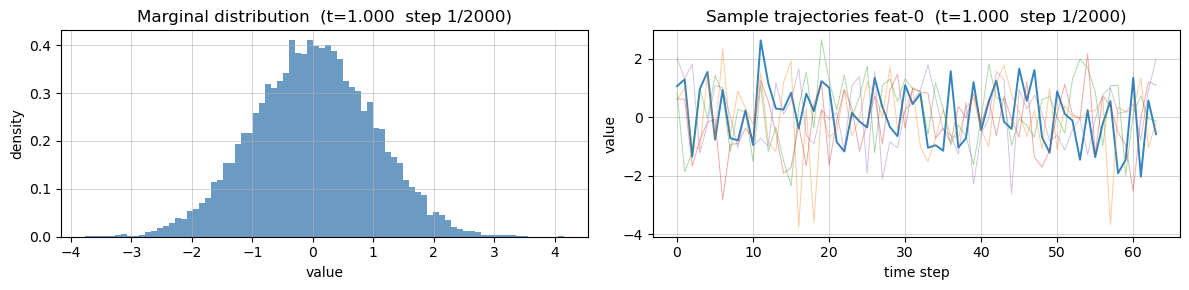

[step  201/2000 | t=0.9001]  mean=-0.0420  std=0.9937  min=-3.9331  max=3.8124  dx_norm=1.18e-03
  skew=-0.0106  kurt(excess)=0.0263
  per-feat std: k0=0.994
  elapsed 137.7s



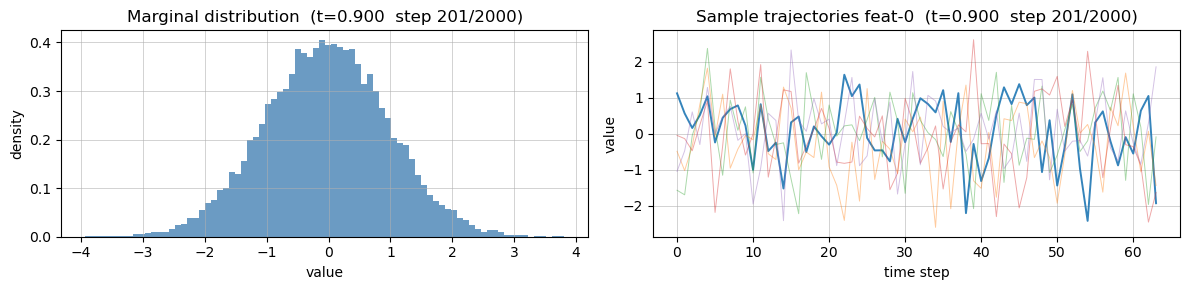

[step  401/2000 | t=0.8001]  mean=-0.0624  std=0.9917  min=-4.2196  max=4.1144  dx_norm=1.11e-03
  skew=-0.0185  kurt(excess)=-0.0230
  per-feat std: k0=0.992
  elapsed 134.0s



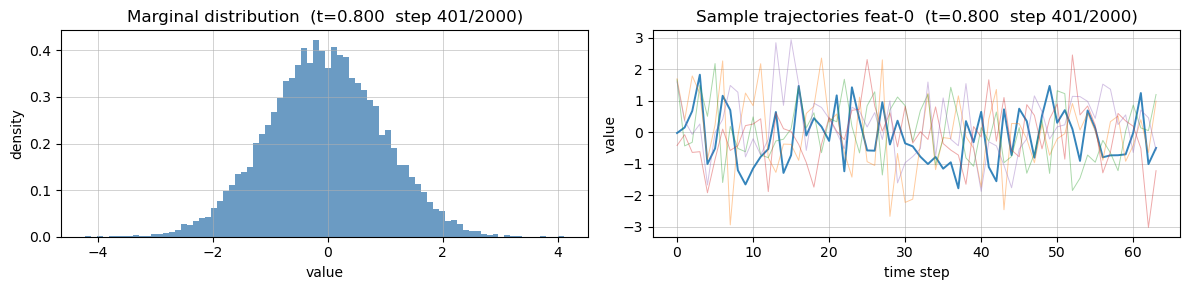

[step  601/2000 | t=0.7002]  mean=-0.0836  std=0.9894  min=-3.9760  max=3.8650  dx_norm=1.03e-03
  skew=-0.0577  kurt(excess)=0.0043
  per-feat std: k0=0.989
  elapsed 130.6s



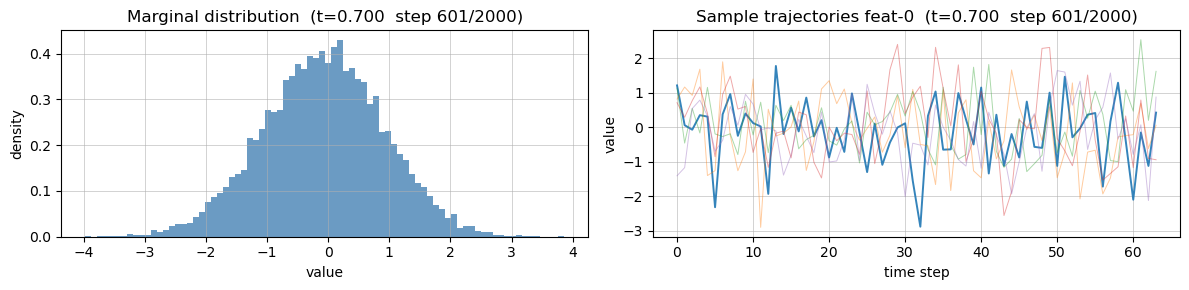

[step  801/2000 | t=0.6002]  mean=-0.1915  std=1.0350  min=-4.5086  max=3.6662  dx_norm=9.59e-04
  skew=-0.0648  kurt(excess)=0.0801
  per-feat std: k0=1.035
  elapsed 133.8s



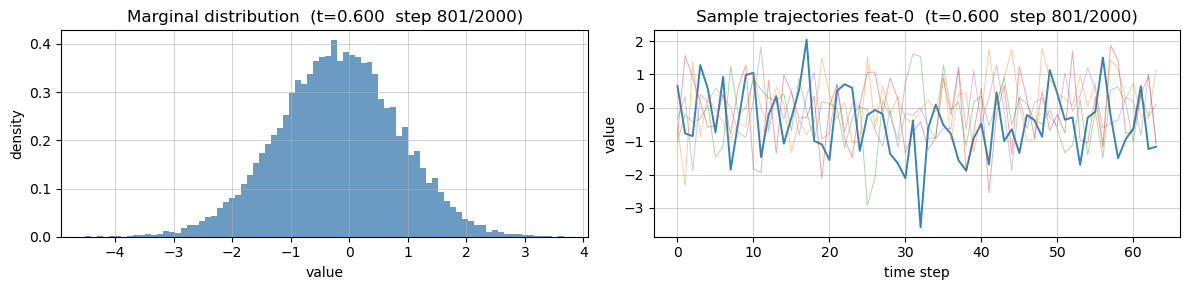

[step 1001/2000 | t=0.5003]  mean=-0.7287  std=1.4027  min=-7.0768  max=5.2109  dx_norm=8.73e-04
  skew=-0.3600  kurt(excess)=0.4250
  per-feat std: k0=1.403
  elapsed 132.2s



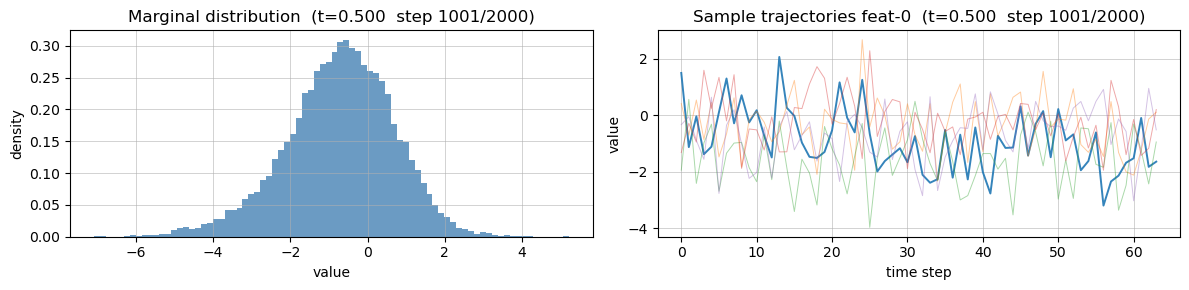

[step 1201/2000 | t=0.4003]  mean=-2.3583  std=3.2642  min=-17.0706  max=8.3000  dx_norm=7.93e-04
  skew=-0.8710  kurt(excess)=1.5563
  per-feat std: k0=3.264
  elapsed 137.3s



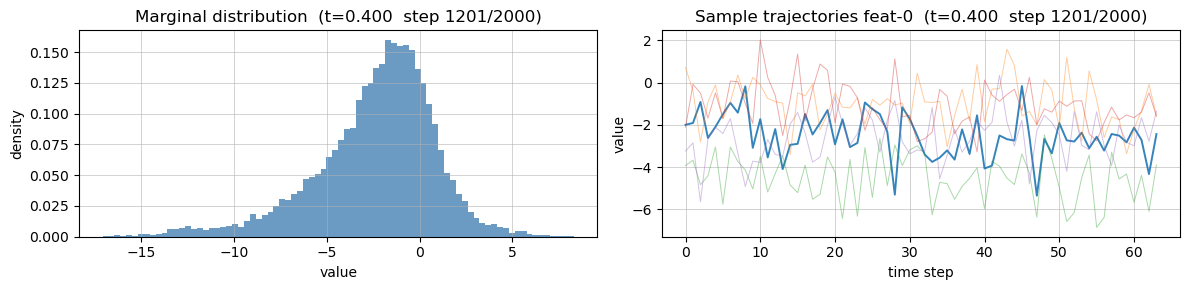

[step 1401/2000 | t=0.3004]  mean=-5.8366  std=7.5500  min=-39.7121  max=15.2508  dx_norm=7.37e-04
  skew=-0.9384  kurt(excess)=1.6383
  per-feat std: k0=7.550
  elapsed 137.3s



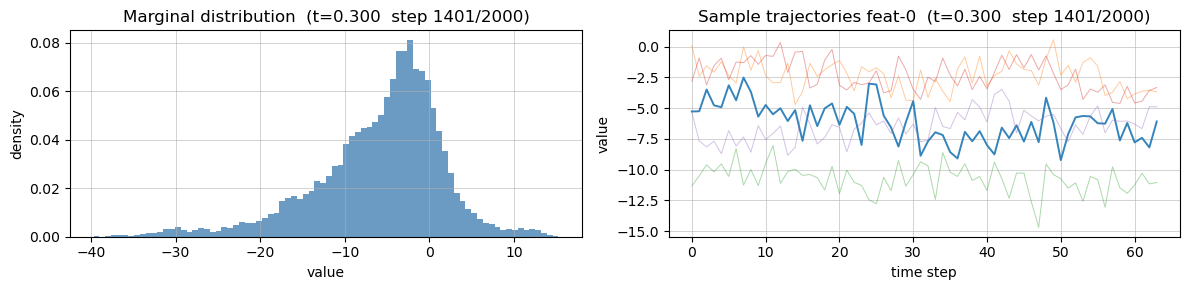

[step 1601/2000 | t=0.2004]  mean=-10.9997  std=13.9300  min=-74.8931  max=26.0475  dx_norm=6.54e-04
  skew=-0.9503  kurt(excess)=1.6690
  per-feat std: k0=13.930
  elapsed 141.0s



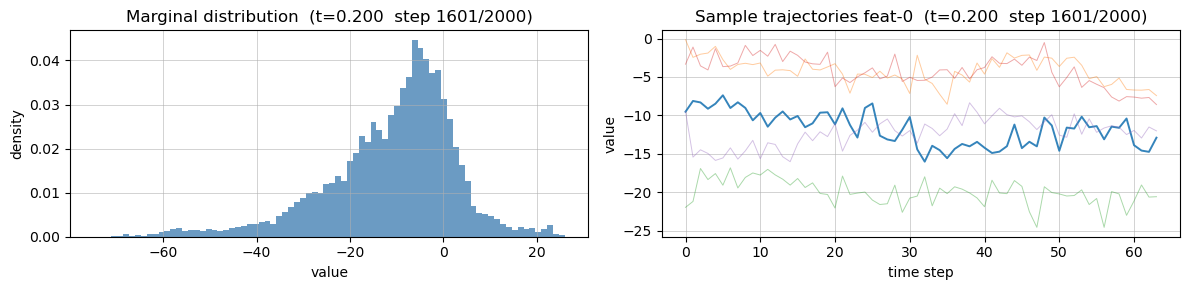

[step 1801/2000 | t=0.1005]  mean=-16.0424  std=20.2014  min=-108.4520  max=38.0417  dx_norm=4.67e-04
  skew=-0.9616  kurt(excess)=1.7053
  per-feat std: k0=20.201
  elapsed 139.1s



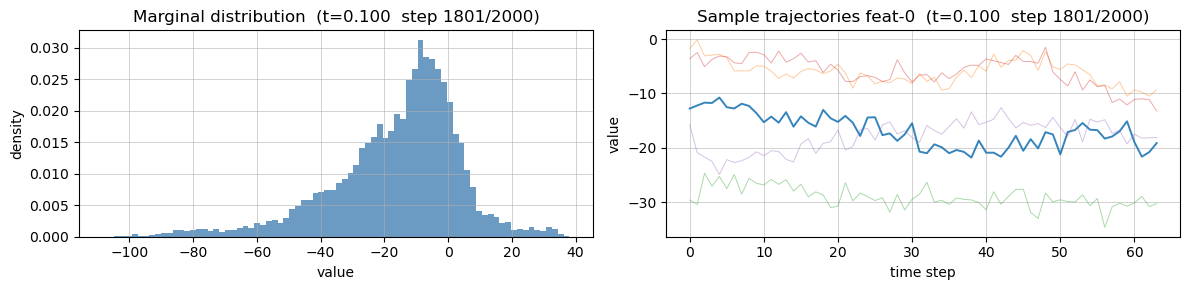

[step 1992/2000 | t=0.0050]  mean=-18.1938  std=22.8881  min=-123.0039  max=42.6523  dx_norm=8.93e-05
  skew=-0.9642  kurt(excess)=1.7105
  per-feat std: k0=22.888
  elapsed 132.5s

[step 1993/2000 | t=0.0045]  mean=-18.1948  std=22.8894  min=-123.0072  max=42.6623  dx_norm=8.66e-05
  skew=-0.9642  kurt(excess)=1.7108
  per-feat std: k0=22.889
  elapsed 0.7s

[step 1994/2000 | t=0.0040]  mean=-18.1958  std=22.8906  min=-122.9946  max=42.6576  dx_norm=8.09e-05
  skew=-0.9642  kurt(excess)=1.7107
  per-feat std: k0=22.891
  elapsed 0.7s

[step 1995/2000 | t=0.0035]  mean=-18.1967  std=22.8915  min=-122.9873  max=42.6656  dx_norm=7.58e-05
  skew=-0.9642  kurt(excess)=1.7107
  per-feat std: k0=22.892
  elapsed 0.7s

[step 1996/2000 | t=0.0030]  mean=-18.1974  std=22.8923  min=-122.9968  max=42.6643  dx_norm=7.10e-05
  skew=-0.9642  kurt(excess)=1.7107
  per-feat std: k0=22.892
  elapsed 0.7s

[step 1997/2000 | t=0.0025]  mean=-18.1981  std=22.8930  min=-122.9877  max=42.6544  dx_norm=6.48e

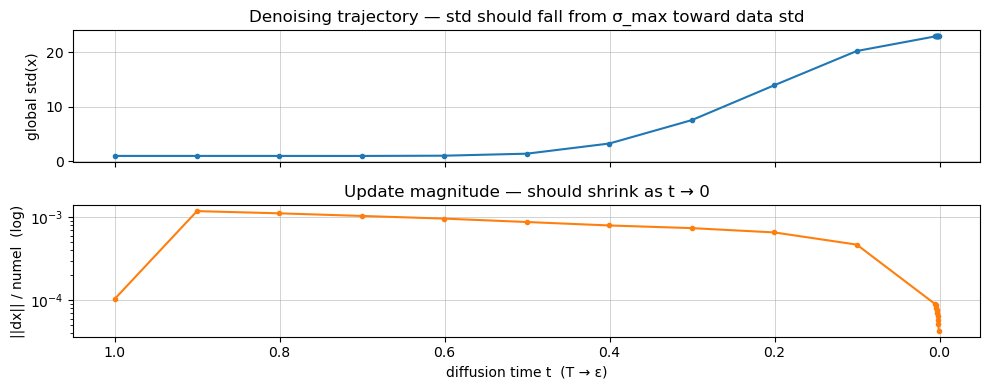

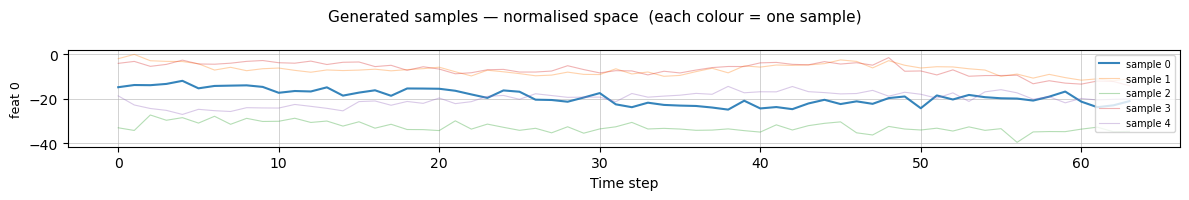

gen_paths shape: (256, 64)


In [14]:
observed_data = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
cond_mask     = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
observed_tp   = torch.linspace(0.0, 1.0, seq_len, device=device)\
                     .unsqueeze(0).expand(N_SAMPLES, -1)

with torch.no_grad():
    samples = processes.reverse_process(
        model         = model,
        shape         = (N_SAMPLES, target_dim, seq_len),
        observed_data = observed_data,
        cond_mask     = cond_mask,
        observed_tp   = observed_tp,
        num_steps     = N_STEPS,
        device        = device,
    )

# gen_paths: (N_SAMPLES, seq_len) — keep paths intact for temporal analysis
gen_paths = samples.cpu().numpy().squeeze(1)
print(f"gen_paths shape: {gen_paths.shape}")

## 3. Generate reference GBM paths

Reference paths are drawn from the same process used in `toy_generation.py`:
log(S_t) = cumsum of i.i.d. N(0, σ²) increments.

In [15]:
rng = np.random.default_rng(SEED)

# Reference: seq_len-1 increments cumsum-ed, prepend X_0=0 to match training data
ref_increments = rng.normal(0.0, REF_STD, size=(N_SAMPLES, seq_len - 1))
ref_paths = np.hstack([
    np.zeros((N_SAMPLES, 1)),
    np.cumsum(ref_increments, axis=1),
])                                          # (N_SAMPLES, seq_len), all start at 0

# Anchor generated paths at 0: subtract each path's own starting value
gen_paths = gen_paths - gen_paths[:, 0:1]  # (N_SAMPLES, seq_len), all start at 0

print(f"ref_paths shape : {ref_paths.shape}")
print(f"ref X_0         : min={ref_paths[:, 0].min():.4f}  max={ref_paths[:, 0].max():.4f}")
print(f"gen X_0         : min={gen_paths[:, 0].min():.4f}  max={gen_paths[:, 0].max():.4f}")
print()
print(f"ref end-point   : mean={ref_paths[:, -1].mean():.4f}  std={ref_paths[:, -1].std():.4f}")
print(f"gen end-point   : mean={gen_paths[:, -1].mean():.4f}  std={gen_paths[:, -1].std():.4f}")

ref_paths shape : (256, 64)
ref X_0         : min=0.0000  max=0.0000
gen X_0         : min=0.0000  max=0.0000

ref end-point   : mean=0.3318  std=8.4090
gen end-point   : mean=-5.8702  std=7.7737


## 4. Increment test

**Rationale**: The marginal distribution of X_t under GBM is N(0, t·σ²) — it changes
with t, so flattening raw path values and running KS gives a meaningless result
(you'd be comparing a heterogeneous mixture to a single Gaussian). The stationary
quantity is the first difference ΔX_t ~ i.i.d. N(0, σ²), which allows the standard
KS / QQ / histogram pipeline to be reused without modification.

In [16]:
gen_inc = np.diff(gen_paths, axis=1).ravel()   # (N_SAMPLES * (seq_len-1),)
ref_inc = np.diff(ref_paths, axis=1).ravel()

ref_dist = scipy_stats.norm(loc=0.0, scale=REF_STD)

ks_stat, ks_p = scipy_stats.ks_2samp(gen_inc, ref_inc)
print(f"Increment KS statistic = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print()

def moments(x, label):
    return {
        "label"          : label,
        "mean"           : np.mean(x),
        "std"            : np.std(x),
        "skewness"       : scipy_stats.skew(x),
        "excess_kurtosis": scipy_stats.kurtosis(x, fisher=True),
        "q01"            : np.quantile(x, 0.01),
        "q99"            : np.quantile(x, 0.99),
    }

df_moments = pd.DataFrame([
    moments(gen_inc, "Generated increments"),
    moments(ref_inc, f"Reference increments N(0,{REF_STD}²)"),
]).set_index("label").round(5)
display(df_moments)

Increment KS statistic = 0.1602  |  p-value = 2.6285e-181



,mean,std,skewness,excess_kurtosis,q01,q99
label,,,,,,
Generated increments,-0.09318,2.25892,-0.07298,3.39717,-6.31870,5.89525
"Reference increments N(0,1.0²)",0.00527,0.99658,-0.03306,0.00250,-2.34696,2.30650


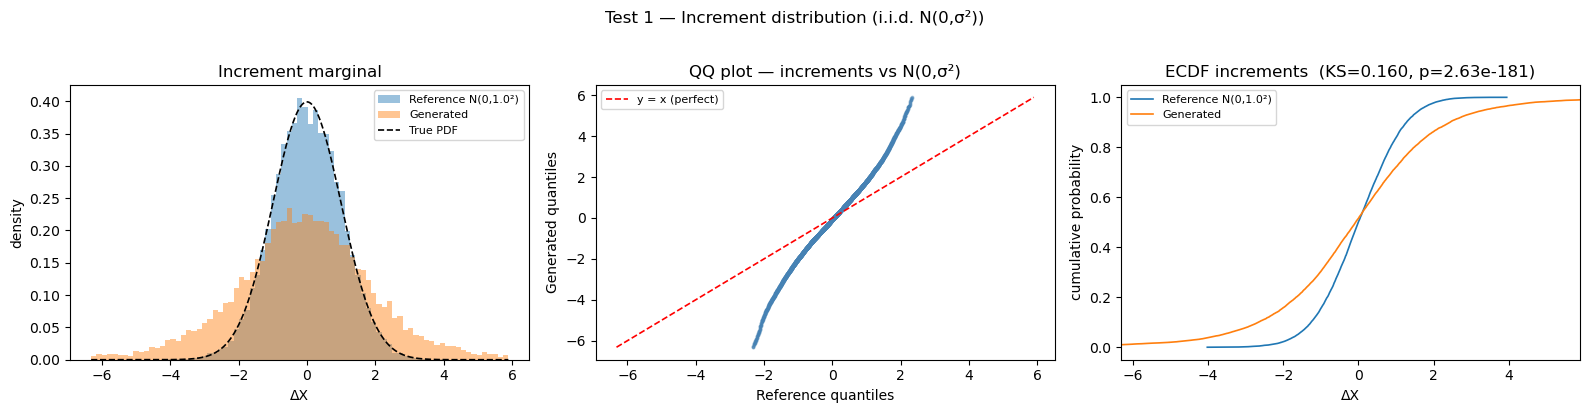

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

combined = np.concatenate([gen_inc, ref_inc])
lo, hi   = np.quantile(combined, [0.005, 0.995])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

# (a) Histogram
ax = axes[0]
ax.hist(ref_inc, bins=bins, density=True, alpha=0.45, label=f"Reference N(0,{REF_STD}²)")
ax.hist(gen_inc, bins=bins, density=True, alpha=0.45, label="Generated")
ax.plot(xs, ref_dist.pdf(xs), "k--", linewidth=1.2, label="True PDF")
ax.set_title("Increment marginal")
ax.set_xlabel("ΔX"); ax.set_ylabel("density"); ax.legend(fontsize=8)

# (b) QQ plot
ax = axes[1]
probs = np.linspace(0.01, 0.99, min(len(gen_inc), 5_000))
q_ref = ref_dist.ppf(probs)
q_gen = np.quantile(gen_inc, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments vs N(0,σ²)")
ax.set_xlabel("Reference quantiles"); ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_inc, f"Reference N(0,{REF_STD}²)", "tab:blue"),
    (gen_inc, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF increments  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("ΔX"); ax.set_ylabel("cumulative probability"); ax.legend(fontsize=8)

plt.suptitle("Test 1 — Increment distribution (i.i.d. N(0,σ²))", y=1.02)
plt.tight_layout()
plt.show()

## 5. Variance fan

**Rationale**: For a random walk, Var[X_t] = t·σ² grows linearly with step t.
This is the single most diagnostic test for non-stationarity: if the model learned
the correct temporal structure, the cross-sectional variance of generated paths must
grow at the same rate as the reference. Saturation indicates the model collapsed to
a bounded (e.g. AR-like) process; super-linear growth indicates it is not anchored
at t=0.

In [18]:
steps = np.arange(1, seq_len + 1)

# gen_var = gen_paths.var(axis=0)   # (seq_len,)
# ref_var = ref_paths.var(axis=0)
# theoretical_var = steps * REF_STD**2

# gen_mean_traj = gen_paths.mean(axis=0)
# ref_mean_traj = ref_paths.mean(axis=0)

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# # (a) Variance fan
# ax = axes[0]
# ax.plot(steps, ref_var,          label="Reference Var[X_t]",    color="tab:blue")
# ax.plot(steps, gen_var,          label="Generated Var[X_t]",    color="tab:orange")
# ax.plot(steps, theoretical_var,  label=f"Theoretical t·σ²={REF_STD}²t",
#         color="black", linestyle="--", linewidth=1.2)
# ax.set_title("Variance fan: Var[X_t] vs step t")
# ax.set_xlabel("step t"); ax.set_ylabel("variance")
# ax.legend(fontsize=8)

# # (b) Mean trajectory  (should be ≈ 0 for zero-drift GBM)
# ax = axes[1]
# ax.plot(steps, ref_mean_traj, label="Reference E[X_t]",  color="tab:blue")
# ax.plot(steps, gen_mean_traj, label="Generated E[X_t]",  color="tab:orange")
# ax.axhline(0, color="black", linestyle="--", linewidth=1.0, label="Theoretical (0)")
# ax.set_title("Mean trajectory: E[X_t] vs step t")
# ax.set_xlabel("step t"); ax.set_ylabel("mean")
# ax.legend(fontsize=8)

# plt.suptitle("Test 2 — Non-stationarity / variance fan", y=1.02)
# plt.tight_layout()
# plt.show()

# # Slope of variance growth: should be ≈ REF_STD²
# gen_slope = np.polyfit(steps, gen_var, 1)[0]
# ref_slope = np.polyfit(steps, ref_var, 1)[0]
# print(f"Variance slope — Generated: {gen_slope:.4f} | "
#       f"Reference: {ref_slope:.4f} | Theoretical: {REF_STD**2:.4f}")

## 6. Sample paths

Visual sanity check. Generated paths should fan out progressively (no mean reversion)
and have no obvious periodicity or banding.

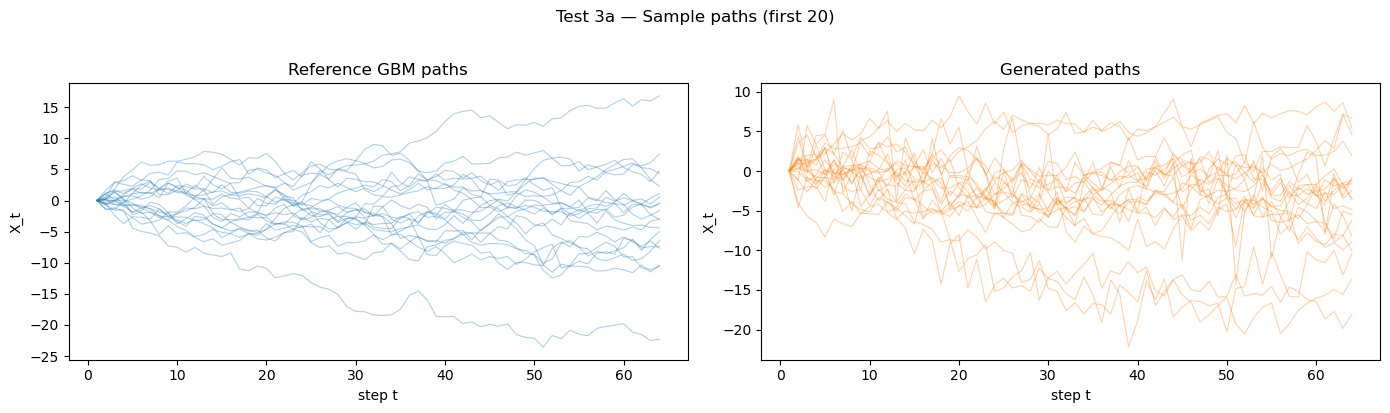

In [19]:
N_SHOW = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for i in range(N_SHOW):
    axes[0].plot(steps, ref_paths[i], alpha=0.35, linewidth=0.8, color="tab:blue")
    axes[1].plot(steps, gen_paths[i], alpha=0.35, linewidth=0.8, color="tab:orange")

for ax, title in zip(axes, ["Reference GBM paths", "Generated paths"]):
    ax.set_title(title)
    ax.set_xlabel("step t")
    ax.set_ylabel("X_t")

plt.suptitle(f"Test 3a — Sample paths (first {N_SHOW})", y=1.02)
plt.tight_layout()
plt.show()

## 7. Autocorrelation of levels vs. increments

**Rationale**: A random walk has two characteristic ACF signatures that together
distinguish it from AR(1) or i.i.d. noise:
- **Levels**: ACF decays very slowly toward zero (high persistence) — *not* the
  geometric decay of AR(1).
- **Increments**: ACF ≈ 0 at all lags ≥ 1 — fully uncorrelated.

If the model collapsed to AR(1)-like behaviour the level ACF will show geometric
decay; if increments are correlated the model introduced spurious momentum.

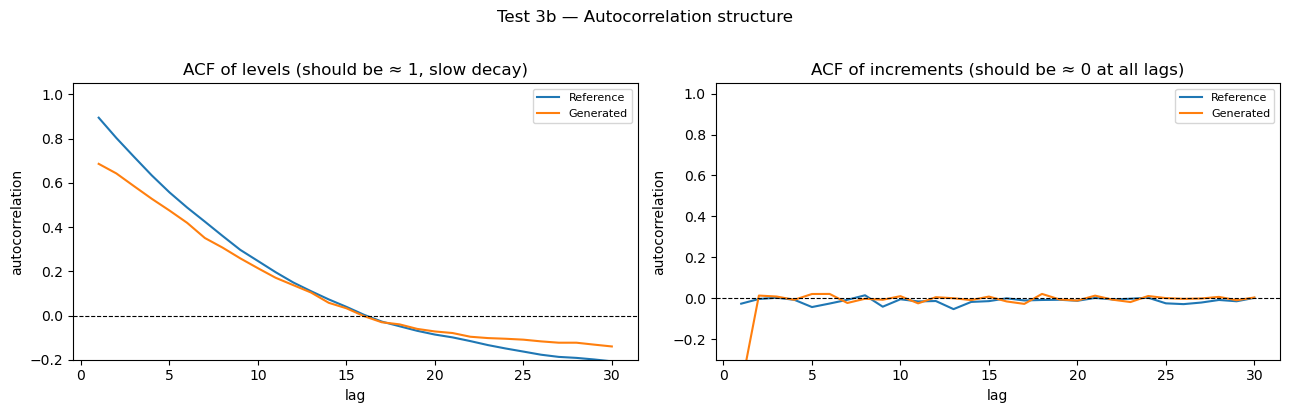

In [20]:
# Average ACF across multiple paths for a more stable estimate
N_ACF_PATHS = min(50, N_SAMPLES)
LAGS        = min(30, seq_len // 2)

def mean_acf(paths, lags, use_diff=False):
    """Mean ACF across paths (ignores confidence bands — we want the average shape)."""
    from statsmodels.tsa.stattools import acf
    acfs = []
    for p in paths[:N_ACF_PATHS]:
        x = np.diff(p) if use_diff else p
        acfs.append(acf(x, nlags=lags, fft=True)[1:])  # skip lag-0 (=1)
    return np.mean(acfs, axis=0)

lag_axis = np.arange(1, LAGS + 1)

gen_acf_levels = mean_acf(gen_paths, LAGS, use_diff=False)
ref_acf_levels = mean_acf(ref_paths, LAGS, use_diff=False)
gen_acf_inc    = mean_acf(gen_paths, LAGS, use_diff=True)
ref_acf_inc    = mean_acf(ref_paths, LAGS, use_diff=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(lag_axis, ref_acf_levels, label="Reference", color="tab:blue")
ax.plot(lag_axis, gen_acf_levels, label="Generated", color="tab:orange")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of levels (should be ≈ 1, slow decay)")
ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.2, 1.05); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(lag_axis, ref_acf_inc, label="Reference", color="tab:blue")
ax.plot(lag_axis, gen_acf_inc, label="Generated", color="tab:orange")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of increments (should be ≈ 0 at all lags)")
ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.3, 1.05); ax.legend(fontsize=8)

plt.suptitle("Test 3b — Autocorrelation structure", y=1.02)
plt.tight_layout()
plt.show()

## 8. Interpretation guide

| Test | Passing (overfit succeeded) | Failing |
|------|----------------------------|---------|
| **Increment KS** (§4) | p > 0.05; QQ points on diagonal | S-curve in QQ (wrong tail shape); large KS stat |
| **Variance fan** (§5) | Var[X_t] grows linearly; slope ≈ σ² | Slope ≪ σ² (bounded/AR-like) or slope ≫ σ² (exploding) |
| **Sample paths** (§6) | Paths fan out, no mean reversion | Paths revert or cluster |
| **Level ACF** (§7) | ACF stays high across all lags | Geometric decay → model learned AR(1) |
| **Increment ACF** (§7) | ACF ≈ 0 at all lags ≥ 1 | Positive autocorrelation → spurious momentum |

**Note**: passing the increment KS test alone is insufficient — an AR(1) with the
right marginal would also pass it. The variance fan + ACF tests are the decisive
checks for whether non-stationarity was captured.